# Swimmer Under Water Fixed Camera Perspective Analysis
```
STUDENT: Jonathan Alexander Chiriboga Guallpa
NEPTUN CODE: DW8WI8
```

In [2]:
from filecmp import cmp

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Deep Network utilities
import torch
import torchvision
from IPython.core.pylabtools import figsize

## Utils
This block contains utility code for presenting information related to this project.

In [3]:
#=================UTILITY FUNCTIONS======================
def show_single_image(img, title: str, grid: str = 'off'):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.title(title)
    plt.axis(grid)
    plt.imshow(img)
    plt.show()


def show_two_img(img1, img2, title1: str, title2: str):

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

    fig, axs = plt.subplots(1, 2, figsize=(15, 15))
    axs[0].imshow(img1)
    axs[0].set_title(title1)

    axs[1].imshow(img2)
    axs[1].set_title(title2)

def show_single_hsv_img(h, s, v, title: str):
    fig, axs = plt.subplots(1, 3, figsize=(15,15))

    axs[0].imshow(h, cmap='hsv')
    axs[0].set_title('Hue (Color)')

    axs[1].imshow(s, cmap='gray')
    axs[1].set_title('Saturation (Bubbles)')

    axs[2].imshow(v, cmap='gray')
    axs[2].set_title('Value (Bright/Gray)')

    plt.show()


def get_video_metadata(video_path: str) -> pd.DataFrame:
    video = cv2.VideoCapture('../data/input/GH017914.MP4')
    metadata = {
        'fps': video.get(cv2.CAP_PROP_FPS),
        'width': int(video.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int (video.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    return pd.DataFrame([metadata])

## Presenting sample images for image analysis

### Image Classical Computer Vision Processing

In [4]:
# Loading and evaluation camera parameters
img_plt = cv2.imread('../data/frames_v2/frame_0100.png')
img_plt_gray = cv2.cvtColor(img_plt, cv2.COLOR_BGR2GRAY)

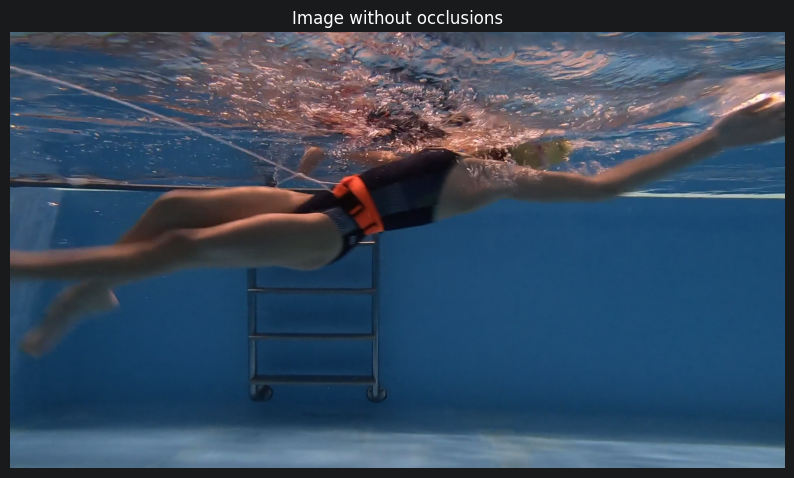

In [6]:
# Image not occluded
img_good = cv2.imread('../data/frames_v2/frame_0050.png')
img_good_gray = cv2.cvtColor(img_good, cv2.COLOR_BGR2GRAY)
show_single_image(img_good, title='Image without occlusions')

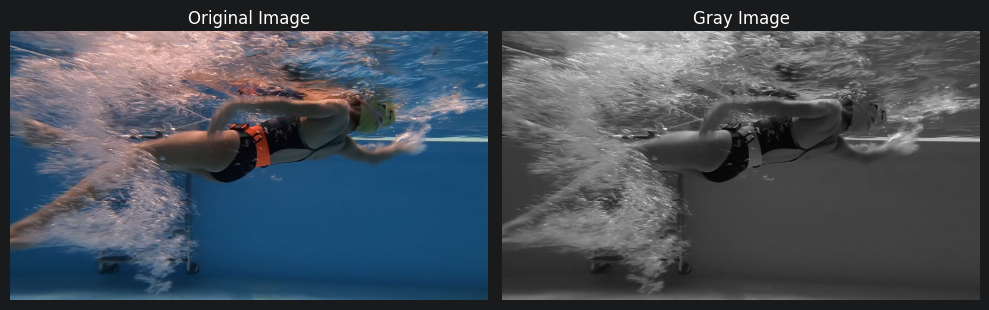

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2 ,figsize=(10,10))

img_show = cv2.cvtColor(img_plt, cv2.COLOR_BGR2RGB)

ax1.imshow(img_show)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(img_plt_gray, cmap='gray')
ax2.set_title('Gray Image')
ax2.axis('off')

plt.tight_layout()
plt.show()

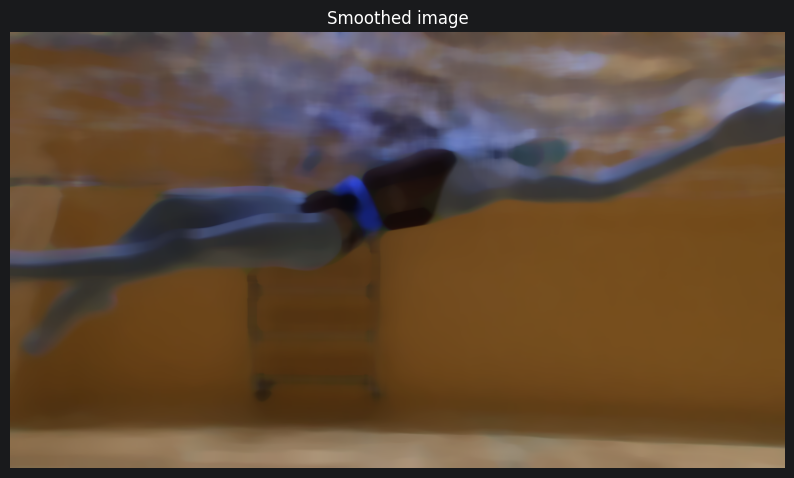

In [11]:
median_blur = cv2.medianBlur(img_good, 41)
img_smooth = cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)
show_single_image(img_smooth, 'Smoothed image')

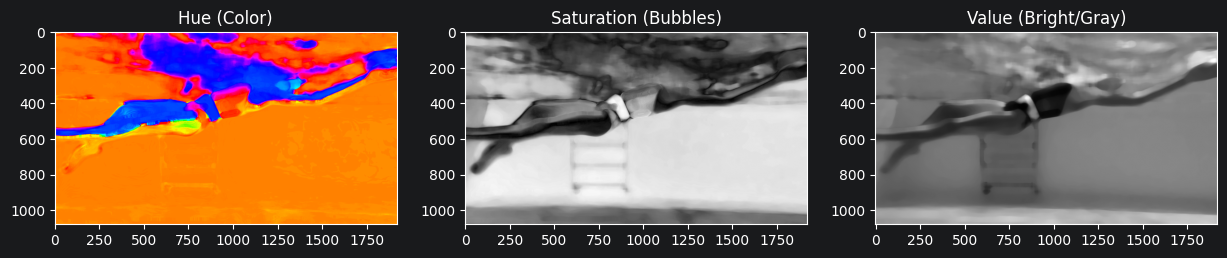

In [12]:
img_hsv = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2HSV)
img_h, img_s, img_v = cv2.split(img_hsv)
show_single_hsv_img(img_h, img_s, img_v, 'Image HSV Color Space Decomposition')

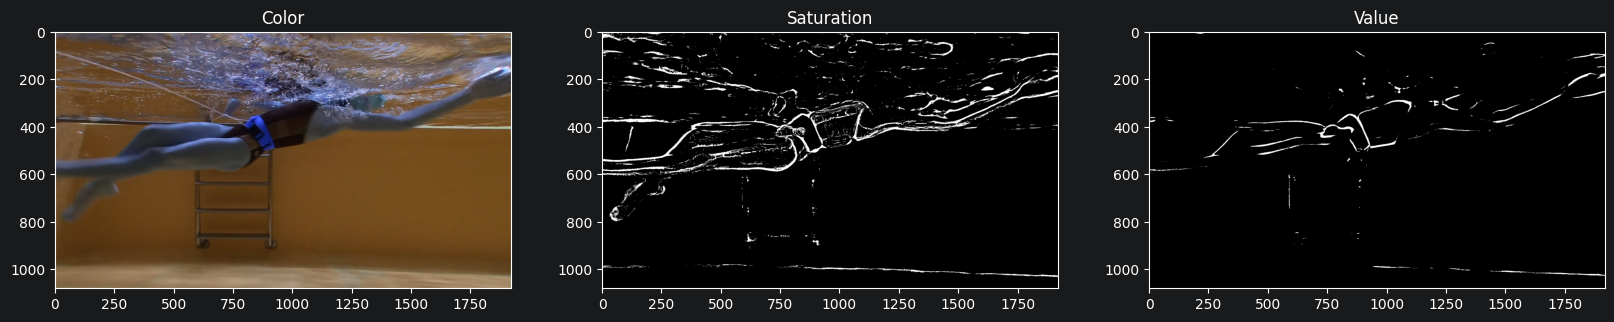

In [13]:
def show_image_thresholded(img_rbg, img_thres1, img_thres2):

    fig, axs = plt.subplots(1, 3, figsize=(20, 7))

    axs[0].imshow(img_rbg)
    axs[0].set_title('Color')
    axs[1].imshow(img_thres1, cmap='gray')
    axs[1].set_title('Saturation')
    axs[2].imshow(img_thres2, cmap='gray')
    axs[2].set_title('Value')

    plt.show()

# HSV Image segmentation

#block size
block_size = 31
c_value = 5

thresh_sat = cv2.adaptiveThreshold(img_s, 255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, c_value)

thresh_val = cv2.adaptiveThreshold(img_v, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, c_value)

show_image_thresholded(img_good, thresh_sat, thresh_val)

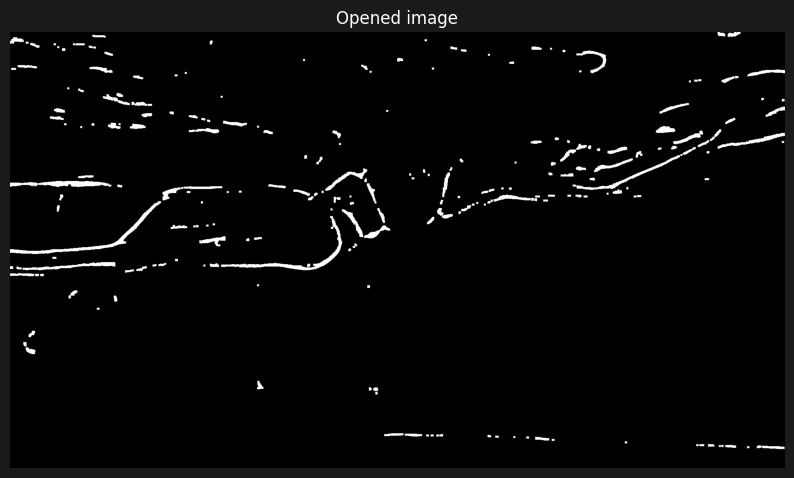

In [22]:
# Morphological operations

#Defining a 5x5 kernel
kernel = np.ones((5, 5), np.uint8)

#open_img = cv2.morphologyEx(thresh_sat, cv2.MORPH_OPEN, kernel)
img_dilated = cv2.dilate(thresh_sat, kernel, iterations=1)

show_single_image(open_img, 'Opened image')

## Testing identifying body points on images

In [10]:
# IMPLEMENTING MEDIAPIPE

# Creates the base object that manages how the neural network works
base_options = python.BaseOptions(model_asset_path='../models/pose_landmarker_lite.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True
)
detector = vision.PoseLandmarker.create_from_options(options)

#Loading image
rgb_img = cv2.cvtColor(img_plt, cv2.COLOR_BGR2RGB)
image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_img)

#Pose detection
detected_points = detector.detect(image)

#Visualize
annotated_image = draw_landmarks_on_image(image.numpy_view(), detected_points)

show_single_image(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR), 'Pose Landmarks')

NameError: name 'python' is not defined